# 465 — Functional-role matching (GAUSSIAN windows)

Same conjunction templates as **460**, but each role box is gated with a **2-D gaussian**
(time × frequency) centred on the box instead of a hard boxcar rectangle. The gaussian is
auto-derived from each box's extent (centre = box midpoint, σ = half-extent /
`GAUSS_SUPPORT_SIGMA`): cells near the centre count fully, the edges taper off — so it
tolerates latency / frequency jitter and drops the boxcar's hard-edge artefact. The
threshold (`ROLE_BOX_MIN_PROP`) and the strict silence gate are unchanged.

The discretized −1/0/+1 map is **identical** to 460 — only the box gate differs
(`shape='gaussian'`). Writes to a **separate** `outputs/pooling/pool_web_gaussian/` so the
boxcar (460) and gaussian results stand side-by-side (490 compares them).


In [1]:
import os, sys
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import display, Markdown, Image
sys.path.insert(0, str(Path('..').resolve()))
from functions import lf_pool as P

INPUT_DIR = Path(r'\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY')
if not INPUT_DIR.exists():
    INPUT_DIR = Path('../01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY').resolve()

print('INPUT_DIR :', INPUT_DIR, '| exists:', INPUT_DIR.exists())
print('OUTPUTS   :', P.OUTPUTS_ROOT)
print('COORDS    :', P.COORDS_DIR, '| exists:', P.COORDS_DIR.exists())
print('conditions:', P.CONDITIONS, '| zones:', P.DEFAULT_ZONES)
print('feature sets:', P.FEATURE_SETS, '| window shapes:', P.WINDOW_SHAPES)


INPUT_DIR : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY | exists: True
OUTPUTS   : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling
COORDS    : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\250_recon\fsaverage\coords | exists: True
conditions: ('audio', 'picture', 'reading') | zones: ('perception', 'pre_articulation', 'audio')
feature sets: ('hg', 'bands15') | window shapes: ('boxcar', 'gaussian')


In [2]:
# ---- knobs ----
USE_DS    = False                    # False: full-res discretized baseline (recommended) · True: ds
GRID      = 'ds' if USE_DS else 'full'
print('grid:', GRID, '| roles:', [r['role'] for r in P.ROLE_PARAMS[GRID]['roles']])


grid: full | roles: ['auditory', 'auditory_v2', 'visual_picture', 'visual_reading', 'picture_stim', 'pic_stim', 'lexical_semantic', 'heteromodal_convergence', 'maintenance', 'premotor planning', 'phonological_encoding', 'motor', 'motor_v2', 'auditory_feedback', 'deactivation', 'NN', 'tag_hga_activation', 'tag_beta_erd', 'tag_low_f_erd', 'tag_theta_tracking', 'ultra_hfa', 'stimulus_active', 'response_active']


## 1 — Load dataset


In [3]:
df_meta, X_full = P.prepare_pooling_dataset(INPUT_DIR)
print('loaded:', len(df_meta), 'rows |', df_meta['condition'].value_counts().to_dict())


[lf_dataset cache miss] params differ — rebuilding
[lf_dataset] detected 27 patient folders under \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY
  loaded 9018 samples
  excluded 177 non-neural channels → 8841 samples
[lf_dataset] canonical dataset ready: 8841 samples · X_3d.shape=(8841, 129, 300)
  cached to \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\_dataset\pooling\_raw_ungated
[lf_pool] 8841 samples, 8841 with a contact key, X_3d=(8841, 129, 300)
loaded: 8841 rows | {'picture': 3013, 'audio': 2972, 'reading': 2856}


## 2 — Concatenate raw dB ERSP (one map per all-3-condition contact)
Identical to 460 — raw ERSP is used directly, no discretization.


In [4]:
df_contacts, X_raw = P.build_concat_raw(df_meta, X_full)
print('contacts:', len(df_contacts), '| X_raw:', X_raw.shape)
df_contacts.head()


[lf_pool] concat-raw: 2856 contacts, all 3 conditions · X_raw=(2856, 129, 900)
contacts: 2856 | X_raw: (2856, 129, 900)


,patient_id,contact_norm,electrode
0,EL030,AL10,A_L10
1,EL030,AL11,A_L11
2,EL030,AL12,A_L12
3,EL030,AL13,A_L13
4,EL030,AL14,A_L14


## 3 — Raw-dB role matching (mirrors poolv2 Apply button exactly)
Per-role `thr` and `frac` come from `roi_config_concatenated.py`.
`role` = most-specific match; `roles_matched` lists all.


[lf_pool] roles_raw run -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\roles_raw\full\runs\20260719_124142
[lf_pool] role table (raw dB): (2856, 7)


,role,n_matched,n_primary
0,tag_low_f_erd,881,424
1,tag_beta_erd,596,411
2,tag_theta_tracking,593,326
3,tag_hga_activation,296,158
4,response_active,242,0
5,auditory,231,217
6,ultra_hfa,141,40
7,stimulus_active,98,0
8,premotor planning,63,63
9,NN,56,48


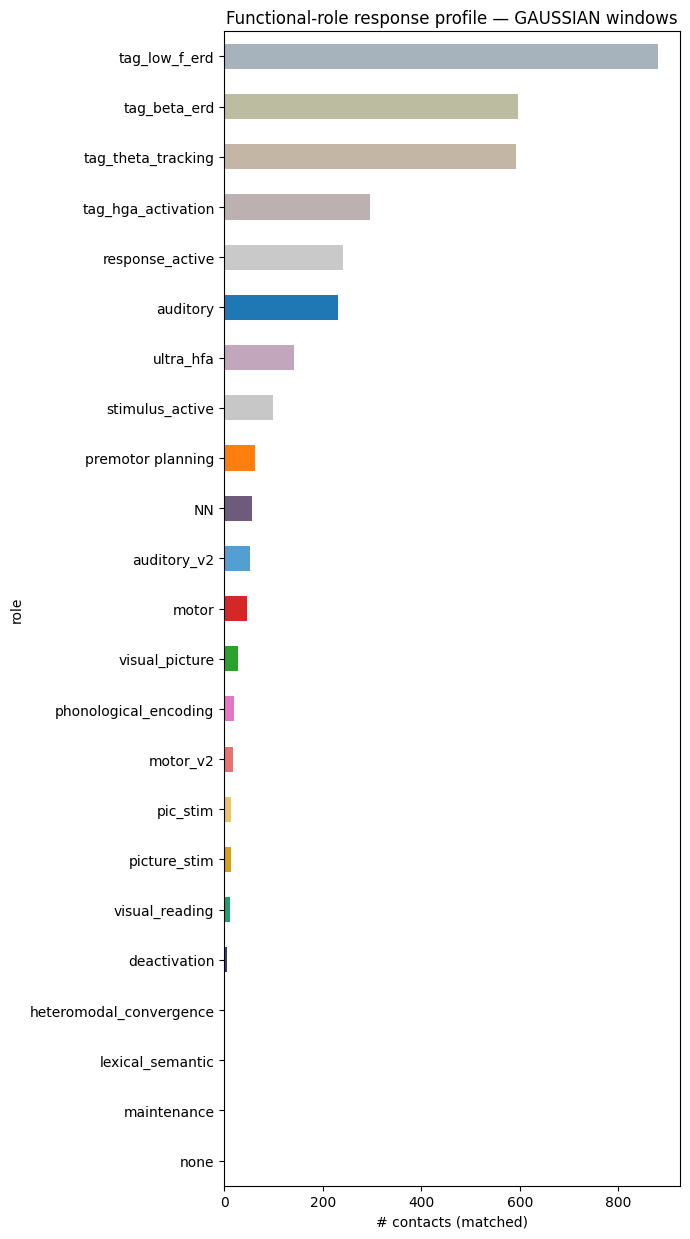

In [5]:
import matplotlib.pyplot as plt
df_role = P.build_role_table_raw(df_contacts, X_raw, grid=GRID)
counts = P.role_counts(df_role)
display(counts)
ax = counts.set_index('role')['n_matched'].plot.barh(figsize=(7, 0.5 * len(counts) + 1),
        color=[P.role_colors(GRID).get(r, '#888') for r in counts['role']])
ax.set_xlabel('# contacts (matched)'); ax.set_title('Functional-role response profile — GAUSSIAN windows')
ax.invert_yaxis(); plt.tight_layout(); plt.show()


## 3b — Role co-occurrence (multi-label overlap, gaussian gate)
Diagonal = total contacts per role; off-diagonal = contacts sharing each role pair.
Compare against 460's boxcar heatmap to see how the soft window shifts overlaps.


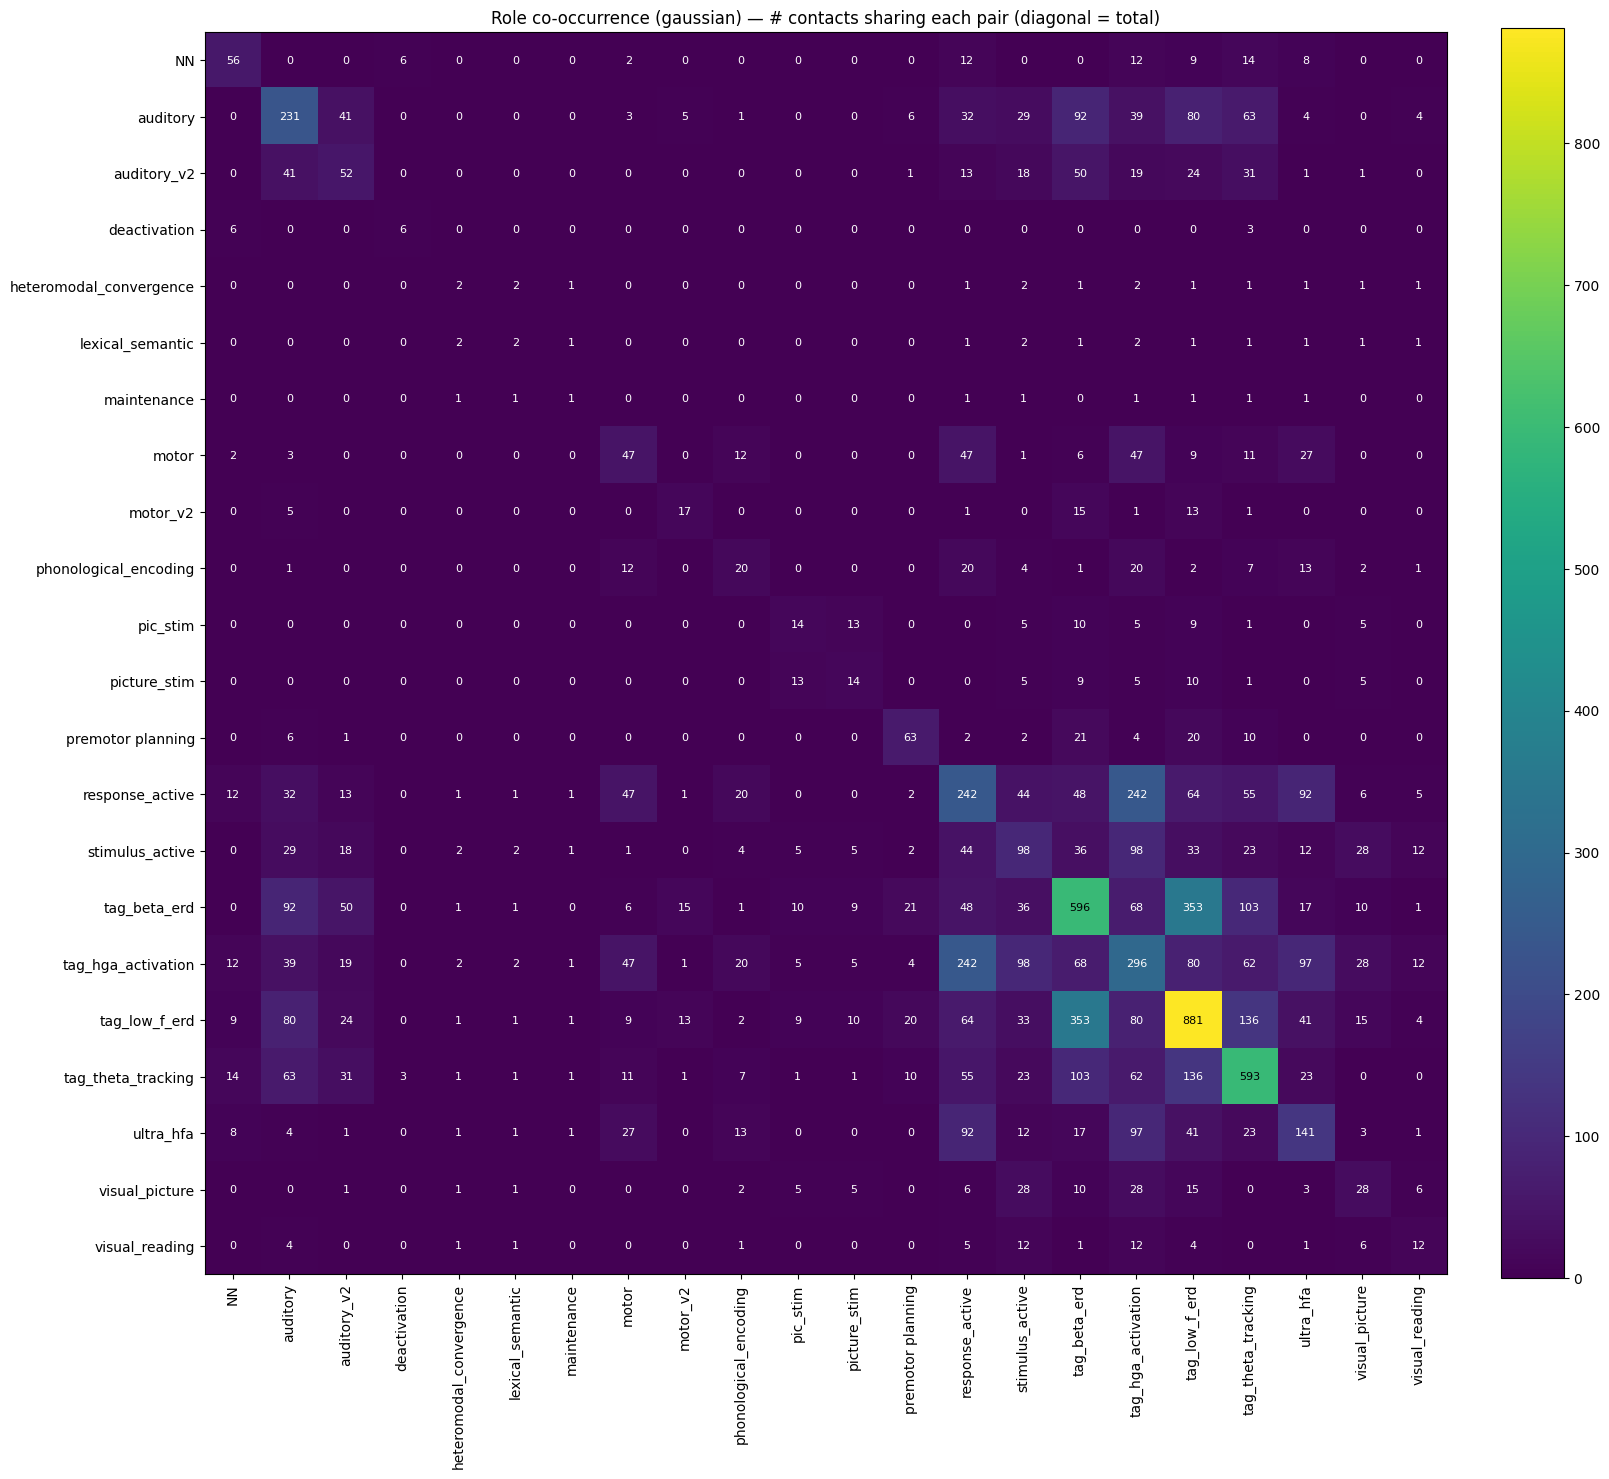

In [6]:
import numpy as np, matplotlib.pyplot as plt
M = P.role_membership(df_role)                       # one row/contact, bool col per matched role
role_cols = [c for c in M.columns if c not in ('patient_id', 'contact_norm')]
B = M[role_cols].to_numpy().astype(int)
C = B.T @ B                                          # co-occurrence counts; diagonal = n_matched
fig, ax = plt.subplots(figsize=(0.6 * len(role_cols) + 3, 0.6 * len(role_cols) + 3))
im = ax.imshow(C, cmap='viridis')
ax.set_xticks(range(len(role_cols))); ax.set_xticklabels(role_cols, rotation=90)
ax.set_yticks(range(len(role_cols))); ax.set_yticklabels(role_cols)
vmax = int(C.max()) if C.size else 1
for i in range(len(role_cols)):
    for j in range(len(role_cols)):
        ax.text(j, i, int(C[i, j]), ha='center', va='center', fontsize=8,
                color='white' if C[i, j] < vmax * 0.6 else 'black')
ax.set_title('Role co-occurrence (gaussian) — # contacts sharing each pair (diagonal = total)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


## 4 — Export for the POOL web page (gaussian)
Writes `contacts_pool.csv` + `pool_index.json` to **`outputs/pooling/pool_web_gaussian/`**
(separate from 460's boxcar export) so `pool.html` can load either set.


In [7]:
coords = P.load_coords()
web = P.export_pool_web(df_role, coords, P.OUTPUTS_ROOT / 'pool_web_gaussian', grid=GRID, df_meta=df_meta)
print('POOL web (gaussian) data ->', web)
# per-role info cards for the web info panel (box+gaussian on a representative ERSP)
P.export_role_info(INPUT_DIR, df_role, P.OUTPUTS_ROOT / 'pool_web_gaussian', grid=GRID)


[lf_pool] POOL samples -> pool_samples.json  (2644 contacts)
[lf_pool] POOL web export -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\pool_web_gaussian  (2644 contacts)
POOL web (gaussian) data -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\pool_web_gaussian
[lf_pool] role_info -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\pool_web_gaussian\role_info.json  (23 roles, 18 cards)


WindowsPath('//nasac-m2.unige.ch/m-HumanNeuronLab/ANALYSIS/FLM/Analysis_LoraFanda/04_FBM_Pooling/outputs/pooling/pool_web_gaussian/role_info.json')